Retail Intelligence Dashboard

I designed and developed an executive retail dashboard that provides leadership with actionable insights into sales performance, customer behavior, product performance, and business trends.

Import Libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

Load Data

In [2]:
orders = pd.read_csv("../data/raw/amazon_retail_data.csv")
customers = pd.read_csv("../data/raw/customers.csv")
products = pd.read_csv("../data/raw/products.csv")

Validate Data

In [3]:
orders.head()

,Order_ID,Order_Date,Payment_Method,Quantity,customer_id,product_id
0,1,2025-10-09,Credit Card,1,99,32
1,2,2025-04-15,Net Banking,2,7,23
2,3,2025-02-02,UPI,1,16,33
3,4,2025-08-27,Net Banking,1,90,3
4,5,2026-07-29,Credit Card,5,60,18


In [4]:
products.head()

,product_id,product_name,category,price
0,1,Product_1,Clothing,1736
1,2,Product_2,Clothing,3796
2,3,Product_3,Home,3099
3,4,Product_4,Books,3252
4,5,Product_5,Clothing,798


In [5]:
customers.head()

,customer_id,customer_name,city,signup_date
0,1,Customer_1,Chennai,2024-07-09
1,2,Customer_2,Mumbai,2024-08-05
2,3,Customer_3,Bangalore,2024-02-13
3,4,Customer_4,Chennai,2024-06-10
4,5,Customer_5,Chennai,2024-07-20


In [6]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Order_ID        100 non-null    int64
 1   Order_Date      100 non-null    str  
 2   Payment_Method  100 non-null    str  
 3   Quantity        100 non-null    int64
 4   customer_id     100 non-null    int64
 5   product_id      100 non-null    int64
dtypes: int64(4), str(2)
memory usage: 4.8 KB


In [7]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    50 non-null     int64
 1   product_name  50 non-null     str  
 2   category      50 non-null     str  
 3   price         50 non-null     int64
dtypes: int64(2), str(2)
memory usage: 1.7 KB


In [8]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    100 non-null    int64
 1   customer_name  100 non-null    str  
 2   city           100 non-null    str  
 3   signup_date    100 non-null    str  
dtypes: int64(1), str(3)
memory usage: 3.3 KB


Check missing values

In [14]:
orders.isnull().sum()

Order_ID          0
Order_Date        0
Payment_Method    0
Quantity          0
customer_id       0
product_id        0
dtype: int64

In [13]:
products.isnull().sum()

product_id      0
product_name    0
category        0
price           0
dtype: int64

In [12]:
customers.isnull().sum()

customer_id      0
customer_name    0
city             0
signup_date      0
dtype: int64

Check for Duplicated Records

In [16]:
orders.duplicated().sum()

np.int64(0)

In [17]:
customers.duplicated().sum()

np.int64(0)

In [18]:
products.duplicated().sum()

np.int64(0)

Dashboards influence business decisions. Validating the source data ensures that KPIs and insights are based on complete, accurate, and reliable information.

Merge data - fact with dim tables for Feature Engineering

In [19]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")

Feature Engineering

In [20]:
#Convert to DateTime format
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [21]:
#Calculate Sales
df["Sales"] = df["Quantity"] * df["price"]

Validate dataset

In [22]:
df.head()

,Order_ID,Order_Date,Payment_Method,Quantity,customer_id,product_id,customer_name,city,signup_date,product_name,category,price,Sales
0,1,2025-10-09,Credit Card,1,99,32,Customer_99,Delhi,2024-02-13,Product_32,Books,1894,1894
1,2,2025-04-15,Net Banking,2,7,23,Customer_7,Bangalore,2024-12-16,Product_23,Books,297,594
2,3,2025-02-02,UPI,1,16,33,Customer_16,Bangalore,2024-08-24,Product_33,Home,759,759
3,4,2025-08-27,Net Banking,1,90,3,Customer_90,Delhi,2024-10-10,Product_3,Home,3099,3099
4,5,2026-07-29,Credit Card,5,60,18,Customer_60,Bangalore,2024-09-13,Product_18,Electronics,4596,22980


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        100 non-null    int64         
 1   Order_Date      100 non-null    datetime64[us]
 2   Payment_Method  100 non-null    str           
 3   Quantity        100 non-null    int64         
 4   customer_id     100 non-null    int64         
 5   product_id      100 non-null    int64         
 6   customer_name   100 non-null    str           
 7   city            100 non-null    str           
 8   signup_date     100 non-null    str           
 9   product_name    100 non-null    str           
 10  category        100 non-null    str           
 11  price           100 non-null    int64         
 12  Sales           100 non-null    int64         
dtypes: datetime64[us](1), int64(6), str(6)
memory usage: 10.3 KB


In [24]:
df.describe()

,Order_ID,Order_Date,Quantity,customer_id,product_id,price,Sales
count,100.000000,100,100.000000,100.000000,100.00000,100.000000,100.000000
mean,50.500000,2025-12-01 22:04:48,3.120000,49.910000,26.78000,2337.290000,7050.060000
min,1.000000,2025-01-04 00:00:00,1.000000,1.000000,1.00000,246.000000,594.000000
25%,25.750000,2025-06-03 12:00:00,2.000000,24.000000,16.00000,954.000000,2352.000000
50%,50.500000,2025-11-15 12:00:00,3.000000,48.000000,26.00000,2173.000000,5788.000000
75%,75.250000,2026-05-31 00:00:00,5.000000,75.250000,39.25000,3396.250000,9793.000000
max,100.000000,2026-12-09 00:00:00,5.000000,100.000000,50.00000,4837.000000,22980.000000
std,29.011492,NaN,1.539251,30.282873,14.30023,1358.376179,5551.786533


Data Validation Summary

Successfully loaded all three datasets.

No missing values were identified.

No duplicate records were found.

Data types were reviewed and verified.

Orders, Customers, and Products were merged successfully.

Sales was calculated dynamically using Quantity × Price.

*************************Dashboard Section**********************

What is a KPI?

Why do executives look at KPIs before charts?

"How is the business performing right now?"

Charts explain why.

KPIs tell you what.

That's why every Amazon Weekly Business Review (WBR) or Monthly Business Review (MBR) starts with metrics before deep dives.

-----------------Executive KPIs------------------

KPI 1 – Total Revenue

How much revenue has the business generated?

The Total Revenue KPI represents the overall business performance during the analysis period and serves as the primary indicator of sales health.

In [25]:
total_revenue = df["Sales"].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹705,006.00


Track Revenue Weekly and Monthly

A single total revenue number only tells you how much you sold.

It doesn't tell you when you sold it.

Revenue trends enable leadership to identify seasonality, growth patterns, campaign effectiveness, and potential operational issues before they significantly impact business performance.

In [26]:
# Ensure Order_Date is datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Year-Week column
df["Year_Week"] = df["Order_Date"].dt.strftime("%Y-W%U")

# Weekly Revenue
weekly_revenue = (
    df.groupby("Year_Week", as_index=False)["Sales"]
      .sum()
      .rename(columns={"Sales": "Weekly_Revenue"})
)

weekly_revenue

,Year_Week,Weekly_Revenue
0,2025-W00,8631
1,2025-W01,2940
2,2025-W05,9059
3,2025-W06,15095
4,2025-W08,15376
...,...,...
59,2026-W44,6038
60,2026-W46,18720
61,2026-W47,7345
62,2026-W48,30026


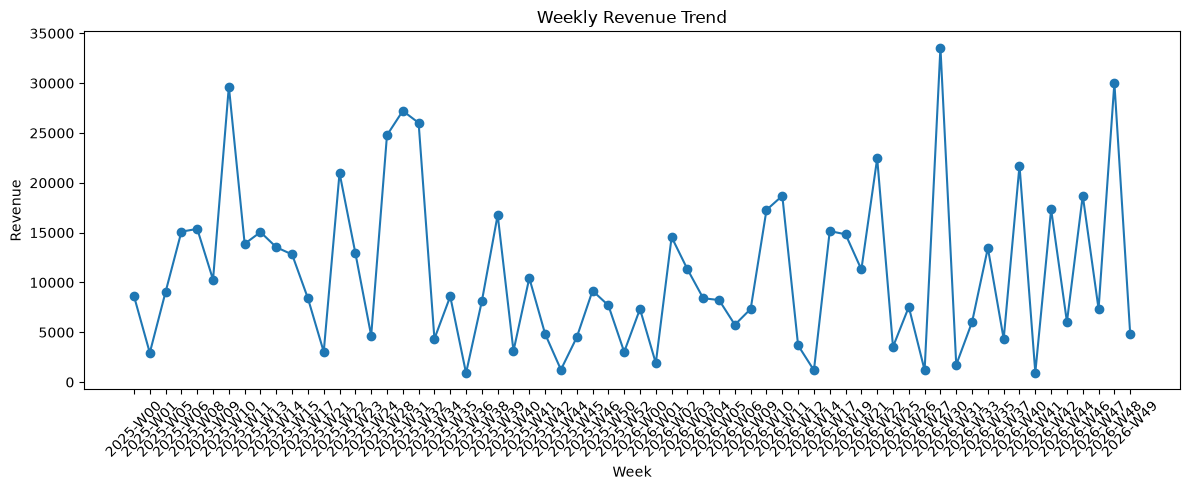

In [28]:
plt.figure(figsize=(12,5))
plt.plot(weekly_revenue["Year_Week"], weekly_revenue["Weekly_Revenue"], marker="o")
plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Create Year-Month column
df["Year_Month"] = df["Order_Date"].dt.to_period("M").astype(str)

# Monthly Revenue
monthly_revenue = (
    df.groupby("Year_Month", as_index=False)["Sales"]
      .sum()
      .rename(columns={"Sales": "Monthly_Revenue"})
)

monthly_revenue

,Year_Month,Monthly_Revenue
0,2025-01,11571
1,2025-02,39530
2,2025-03,53817
3,2025-04,42815
4,2025-05,10030
5,2025-06,38599
6,2025-07,24778
7,2025-08,57584
8,2025-09,34405
9,2025-10,18404


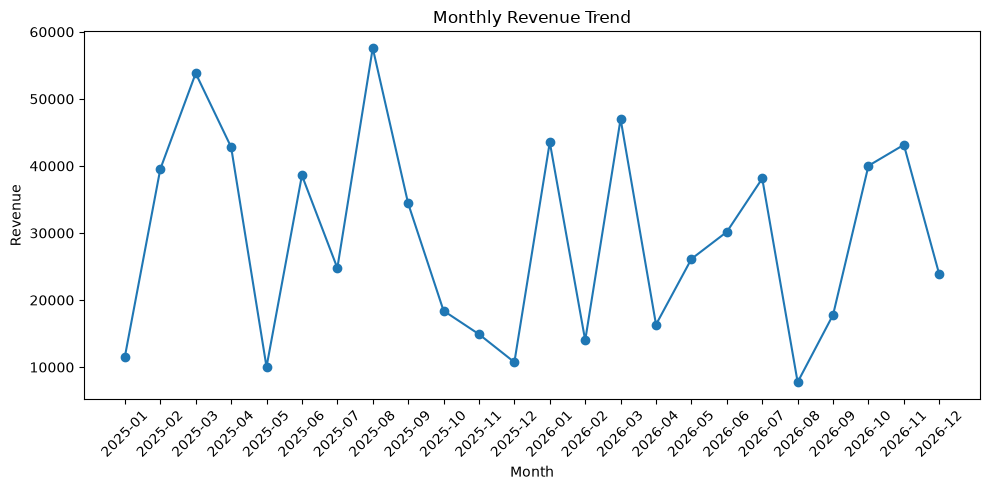

In [29]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["Year_Month"], monthly_revenue["Monthly_Revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Month-over-Month (MoM) Growth %

How much did revenue increase or decrease compared to the previous month?

In [31]:
monthly_revenue["MoM_Growth_%"] = (
    monthly_revenue["Monthly_Revenue"]
    .pct_change() * 100
)
monthly_revenue.head()

,Year_Month,Monthly_Revenue,MoM_Growth_%
0,2025-01,11571,NaN
1,2025-02,39530,241.629937
2,2025-03,53817,36.142171
3,2025-04,42815,-20.443354
4,2025-05,10030,-76.573631


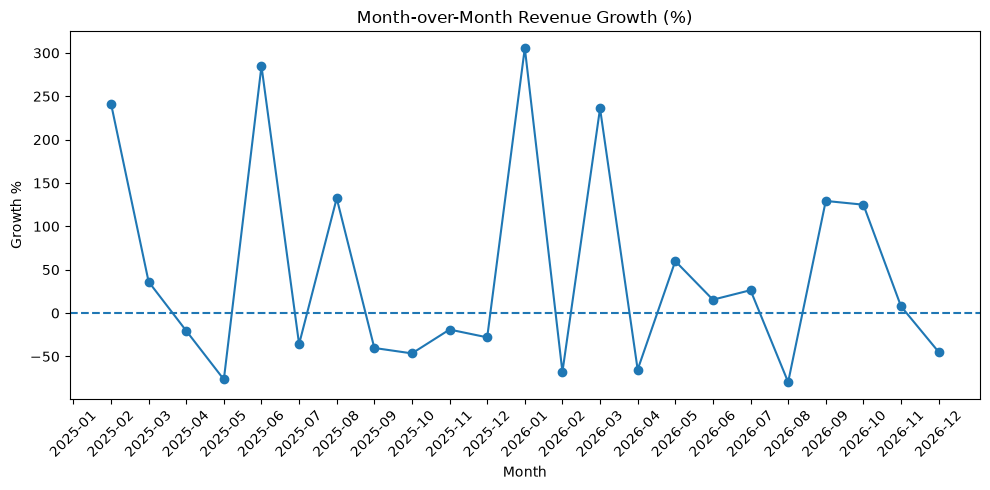

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue["Year_Month"],
    monthly_revenue["MoM_Growth_%"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Month-over-Month Revenue Growth (%)")
plt.xlabel("Month")
plt.ylabel("Growth %")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Positive MoM growth indicates business expansion, while negative growth signals potential issues requiring investigation. Monitoring MoM growth helps leadership identify changing business momentum.

Recommendation

Investigate months with negative growth.

Compare with promotions and marketing campaigns.

Forecast future revenue trends.

Week-over-Week (WoW) Growth %

In [33]:
weekly_revenue["WoW_Growth_%"] = (
    weekly_revenue["Weekly_Revenue"]
    .pct_change() * 100
)

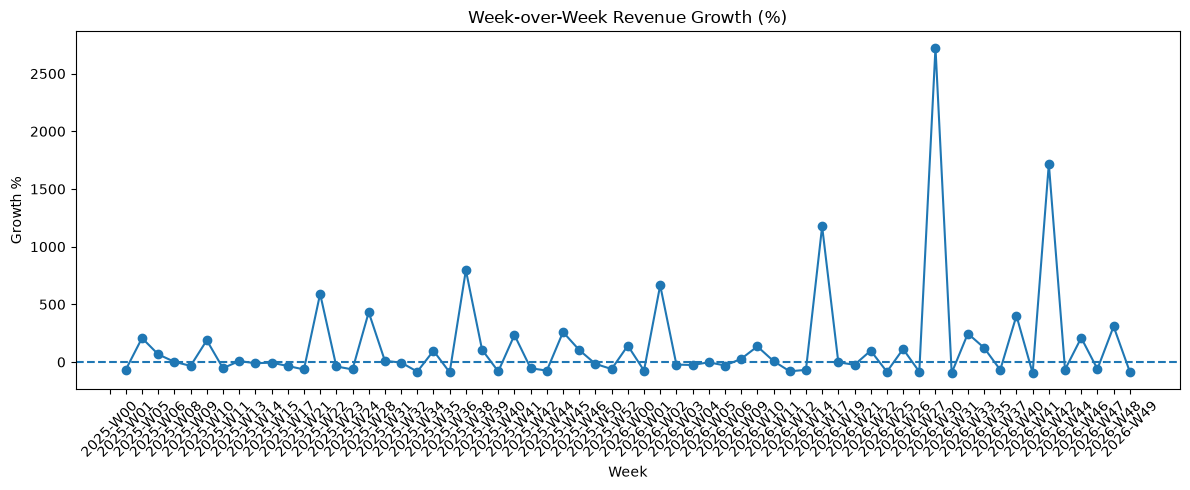

In [34]:
plt.figure(figsize=(12,5))

plt.plot(
    weekly_revenue["Year_Week"],
    weekly_revenue["WoW_Growth_%"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Week-over-Week Revenue Growth (%)")
plt.xlabel("Week")
plt.ylabel("Growth %")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

WoW growth provides early signals of changing customer demand, campaign effectiveness, or operational issues. Unlike monthly trends, weekly monitoring enables faster corrective actions.

Recommendation

Monitor weeks with significant declines.

Compare with campaign launches and operational events.

Investigate sudden spikes to identify successful initiatives that can be replicated.

Revenue grew by x% month-over-month, indicating positive business momentum. The next step would be to determine whether this growth was driven by increased order volume, higher average order value, or changes in product mix. That analysis would guide decisions on marketing, inventory, and customer engagement.


In [44]:
from pathlib import Path
print("Current working directory:")
print(Path.cwd())

Current working directory:
c:\Users\Sandhya Jai\Documents\PythonAnalytics\notebooks


In [1]:
import sys
from pathlib import Path

# Get the project root (one level above notebooks)
PROJECT_ROOT = Path.cwd().parent

# Add it to Python's search path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\Sandhya Jai\Documents\PythonAnalytics


In [2]:
from src.data_loader import load_data

df = load_data()

df.head()

===== DEBUGGING PATHS =====
__file__ = c:\Users\Sandhya Jai\Documents\PythonAnalytics\src\data_loader.py
PROJECT_ROOT = C:\Users\Sandhya Jai\Documents\PythonAnalytics
DATA_DIR = C:\Users\Sandhya Jai\Documents\PythonAnalytics\data\raw
DATA_DIR exists? True
amazon file exists? True


,Order_ID,Order_Date,Payment_Method,Quantity,customer_id,product_id,customer_name,city,signup_date,product_name,category,price
0,1,2025-10-09,Credit Card,1,99,32,Customer_99,Delhi,2024-02-13,Product_32,Books,1894
1,2,2025-04-15,Net Banking,2,7,23,Customer_7,Bangalore,2024-12-16,Product_23,Books,297
2,3,2025-02-02,UPI,1,16,33,Customer_16,Bangalore,2024-08-24,Product_33,Home,759
3,4,2025-08-27,Net Banking,1,90,3,Customer_90,Delhi,2024-10-10,Product_3,Home,3099
4,5,2026-07-29,Credit Card,5,60,18,Customer_60,Bangalore,2024-09-13,Product_18,Electronics,4596


In [12]:
from src.data_loader import load_data
from src.feature_engineering import prepare_data

# Load Data
df = load_data()

# Feature Engineering
df = prepare_data(df)

df.head()

,Order_ID,Order_Date,Payment_Method,Quantity,customer_id,product_id,customer_name,city,signup_date,product_name,...,Year,Month,Month_Number,Quarter,Week,Day,Day_Name,Year_Month,Year_Week,Customer_Tenure_Days
0,1,2025-10-09,Credit Card,1,99,32,Customer_99,Delhi,2024-02-13,Product_32,...,2025,October,10,4,41,9,Thursday,2025-10,2025-W41,604
1,2,2025-04-15,Net Banking,2,7,23,Customer_7,Bangalore,2024-12-16,Product_23,...,2025,April,4,2,16,15,Tuesday,2025-04,2025-W16,120
2,3,2025-02-02,UPI,1,16,33,Customer_16,Bangalore,2024-08-24,Product_33,...,2025,February,2,1,5,2,Sunday,2025-02,2025-W05,162
3,4,2025-08-27,Net Banking,1,90,3,Customer_90,Delhi,2024-10-10,Product_3,...,2025,August,8,3,35,27,Wednesday,2025-08,2025-W35,321
4,5,2026-07-29,Credit Card,5,60,18,Customer_60,Bangalore,2024-09-13,Product_18,...,2026,July,7,3,31,29,Wednesday,2026-07,2026-W31,684


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_ID              100 non-null    int64         
 1   Order_Date            100 non-null    datetime64[us]
 2   Payment_Method        100 non-null    str           
 3   Quantity              100 non-null    int64         
 4   customer_id           100 non-null    int64         
 5   product_id            100 non-null    int64         
 6   customer_name         100 non-null    str           
 7   city                  100 non-null    str           
 8   signup_date           100 non-null    datetime64[us]
 9   product_name          100 non-null    str           
 10  category              100 non-null    str           
 11  price                 100 non-null    int64         
 12  Sales                 100 non-null    int64         
 13  Year                  100 non-nu

In [9]:
from src.metrics import (
    total_revenue,
    total_orders,
    total_customers,
    average_order_value,
    customer_revenue,
    city_sales,
    monthly_revenue,
    weekly_revenue,
    mom_growth,
    wow_growth,
    top_products,
    category_sales,
)

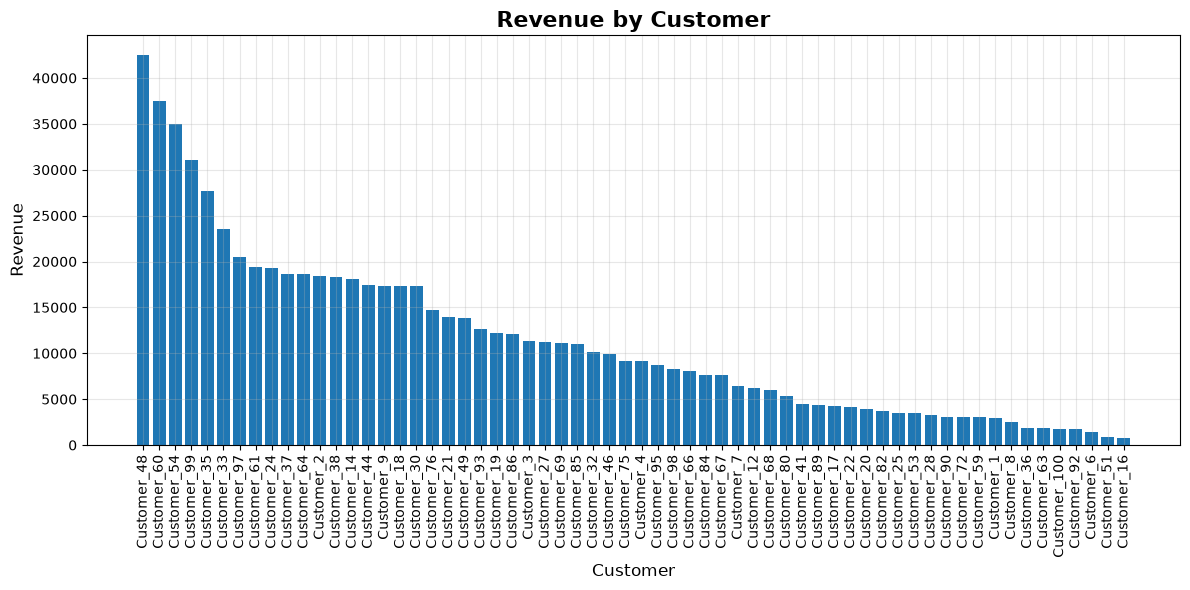

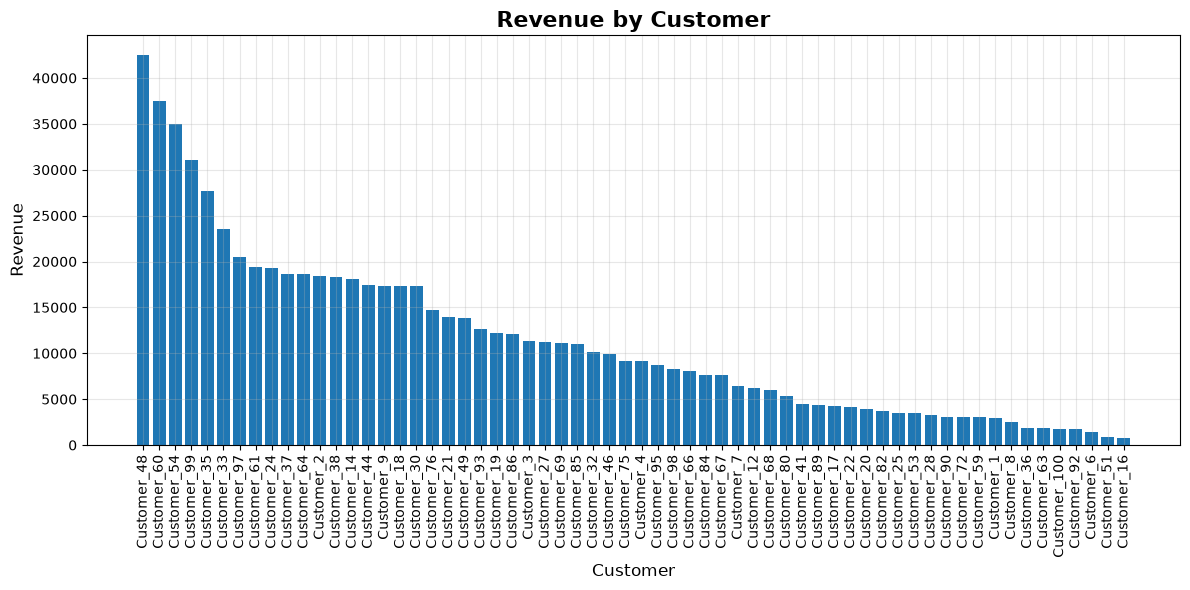

In [5]:
from src.metrics import customer_revenue, city_sales
from src.visualization import (
    plot_customer_revenue,
    plot_city_sales
)

customer_df = customer_revenue(df)
city_df = city_sales(df)

plot_customer_revenue(customer_df)

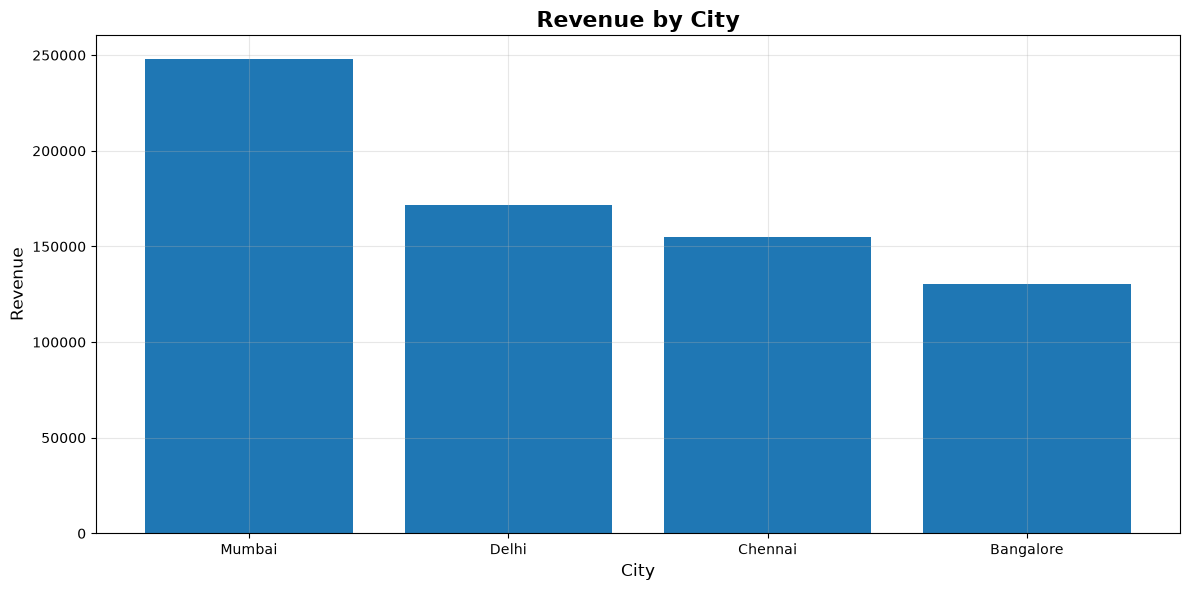

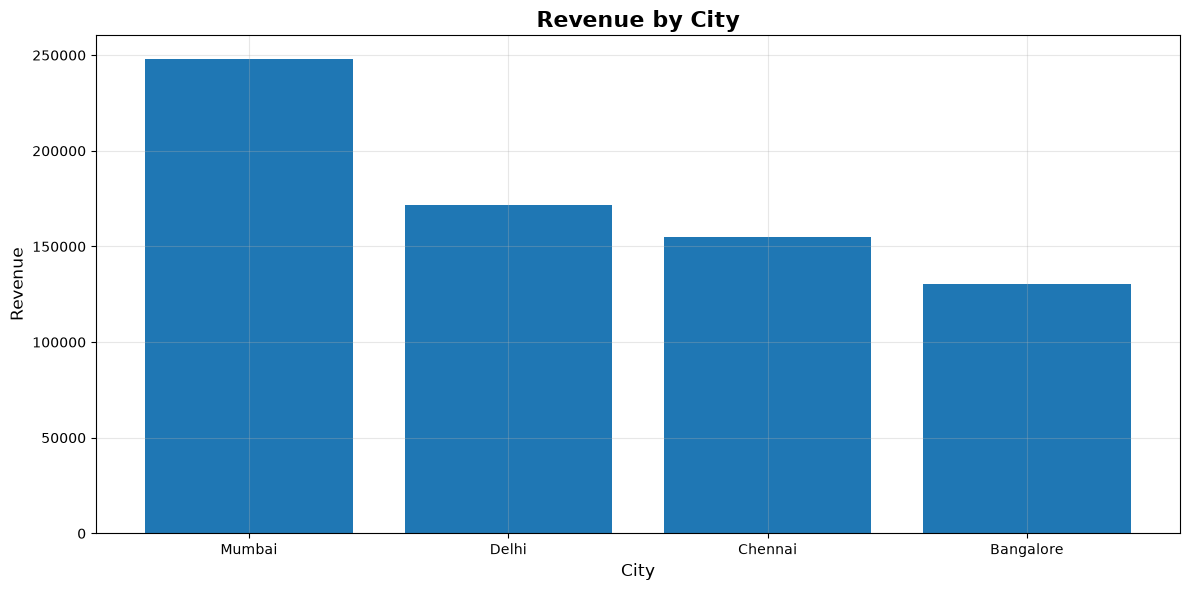

In [6]:
plot_city_sales(city_df)

In [10]:
from src.business_insights import (
    executive_summary,
    revenue_growth_insights,
    top_product_insights,
    city_insights,
    recommendations,
)

In [11]:
summary = executive_summary(
    total_revenue(df),
    total_orders(df),
    total_customers(df),
    average_order_value(df),
)

for item in summary:
    print("•", item)

• Total Revenue generated is ₹705,006.00.
• 100 orders were placed by 62 unique customers.
• Average Order Value is ₹7,050.06.
